# Download and explore weather for all Yelp dataset locations

## tl;dr

Download or reuse weather for **150,346 businesses**, **111 ERA5 cells**, and **11,737,584 hourly rows**, then explore them locally.
The complete download yields **488,955 complete UTC daily rows** and
**15,984 complete monthly rows**. This notebook checks coverage, compares selected
locations, and exports those two weather summaries.

## Context & Methods

Weather is shared at the nearest 0.25° ERA5 cell, without elevation downscaling.
Daily means combine hourly sums/counts. Rain at `t` belongs to the preceding hour,
so its UTC day is `(t - 1 hour).floor("D")`. Unknown and partial rain totals stay missing;
only complete days and complete calendar months enter summaries.

Yelp timestamp timezones remain unresolved; no activity-weather time join or causal
analysis is performed. Cell estimates are not street-level observations or citywide normals.
Sources: [dataset guide](../docs/weather-data.md), [Open-Meteo ERA5 distribution and attribution](https://github.com/open-meteo/open-data),
[variable documentation](https://open-meteo.com/en/docs/historical-weather-api). Yelp retains its own terms.

Run `uv sync --frozen --group notebooks`, then open this notebook with `.venv/bin/python`.
Run cells in order. Completed local downloads are reused; acquisition runs entirely in this notebook.

In [1]:
import calendar
import csv
import gzip
import hashlib
import http.client
import json
import math
import os
import re
import time
from collections import Counter
from datetime import UTC, datetime, timedelta
from importlib.metadata import version
from pathlib import Path
from urllib.parse import urlsplit

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from omfiles import OmFileReader

PROJECT_ROOT = next(
    (
        path
        for path in (Path.cwd(), *Path.cwd().parents)
        if (path / "pyproject.toml").is_file() and (path / "notebooks").is_dir()
    ),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Run from this repository or its notebooks directory.")
RAW_DIR = PROJECT_ROOT / "data/raw/yelp_exploration"
WEATHER_DIR = PROJECT_ROOT / "data/processed/yelp_weather"
OUTPUT_DIR = PROJECT_ROOT / "data/processed/yelp_weather_exploration"
CHUNK_ROWS = 100_000
SELECTED_LOCATIONS = [("Philadelphia", "PA"), ("Edmonton", "AB"), ("Tampa", "FL")]
VARIABLES = ["temperature_2m", "relative_humidity_2m", "precipitation", "wind_speed_10m"]
HOURLY_COLUMNS = ["weather_cell_id", "timestamp_utc", *VARIABLES]
assert CHUNK_ROWS > 0 and OUTPUT_DIR.resolve() != WEATHER_DIR.resolve()
pd.set_option("display.max_columns", 12)
plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.25})

## Download data

For a fresh download, first run [notebook 01](01_yelp_dataset_exploration.ipynb) to stage
`business.jsonl` and `checkin.jsonl` under `RAW_DIR`. This section prepares all-business
mapping and downloads only the ERA5 grid/time slices needed. It needs internet access
for missing years, no API key, and the initial acquisition can take a while.

Completed years are reused only after SHA-256 validation. A complete cached rerun makes
no network calls and leaves its scope, mapping, weather files, and acquisition manifest
unchanged. Changed source bytes require a new `WEATHER_DIR`. Keep the hourly CSVs,
business mapping, cell table, scope/acquisition manifests, and `ATTRIBUTION.txt`.
Coverage checks and source metadata live in the two manifests.

In [2]:
def file_sha256(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as stream:
        for block in iter(lambda: stream.read(8 * 1024**2), b""):
            digest.update(block)
    return digest.hexdigest()


def write_json_atomic(path, value):
    temporary = path.with_suffix(path.suffix + ".tmp")
    try:
        temporary.write_text(json.dumps(value, indent=2, sort_keys=True) + "\n", encoding="utf-8")
        os.replace(temporary, path)
    finally:
        temporary.unlink(missing_ok=True)


def write_csv_atomic(path, header, rows):
    temporary = path.with_suffix(path.suffix + ".tmp")
    try:
        with temporary.open("w", newline="", encoding="utf-8") as stream:
            writer = csv.writer(stream)
            writer.writerow(header)
            writer.writerows(rows)
        os.replace(temporary, path)
    finally:
        temporary.unlink(missing_ok=True)


def jsonl_records(path, metadata):
    before, digest = path.stat(), hashlib.sha256()
    with path.open("rb") as stream:
        for line in stream:
            digest.update(line)
            record = json.loads(line)
            assert isinstance(record, dict), f"Expected JSON objects in {path.name}."
            yield record
    after = path.stat()
    assert (before.st_ino, before.st_size, before.st_mtime_ns) == (
        after.st_ino,
        after.st_size,
        after.st_mtime_ns,
    )
    metadata.update(path=str(path.resolve()), size_bytes=after.st_size, sha256=digest.hexdigest())

In [3]:
def prepare_scope(directory, raw_dir=RAW_DIR):
    directory, raw_dir = Path(directory), Path(raw_dir)
    paths = [
        directory / name
        for name in ["scope.json", "business_weather_mapping.csv", "weather_cells.csv"]
    ]
    raw_paths = {"businesses": raw_dir / "business.jsonl", "checkins": raw_dir / "checkin.jsonl"}
    if all(path.is_file() for path in paths):
        scope = json.loads(paths[0].read_text())
        for label, raw_path in raw_paths.items():
            if raw_path.is_file():
                assert file_sha256(raw_path) == scope["sources"][label]["sha256"], (
                    "Yelp inputs changed; use a new WEATHER_DIR."
                )
        return scope
    if any(path.exists() for path in paths):
        raise FileNotFoundError(
            "Scope artifacts are incomplete; restore them or use a new WEATHER_DIR."
        )
    if not all(path.is_file() for path in raw_paths.values()):
        raise FileNotFoundError("Stage business.jsonl and checkin.jsonl with notebook 01 first.")
    businesses, sources = {}, {"businesses": {}, "checkins": {}}
    for record in jsonl_records(raw_paths["businesses"], sources["businesses"]):
        business_id = record["business_id"]
        assert (
            isinstance(business_id, str) and business_id.strip() and business_id not in businesses
        )
        assert isinstance(record["city"], str) and isinstance(record["state"], str)
        latitude, longitude = float(record["latitude"]), float(record["longitude"])
        assert math.isfinite(latitude) and -90 <= latitude <= 90
        assert math.isfinite(longitude) and -180 <= longitude <= 180
        latitude_index = math.floor(latitude * 4 + 0.5)
        longitude_index = (math.floor(longitude * 4 + 0.5) + 720) % 1440 - 720
        cell_id = f"era5_{latitude_index}_{longitude_index}"
        businesses[business_id] = [
            record["city"],
            record["state"],
            latitude,
            longitude,
            cell_id,
            latitude_index / 4,
            longitude_index / 4,
            0,
            "",
            "",
        ]
    assert businesses, "No businesses found."
    checkin_ids, first, last, total = set(), "", "", 0
    timestamp_pattern = re.compile(r"\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}")
    for record in jsonl_records(raw_paths["checkins"], sources["checkins"]):
        business_id = record["business_id"]
        assert business_id in businesses and business_id not in checkin_ids
        checkin_ids.add(business_id)
        dates = record["date"]
        assert isinstance(dates, str)
        if not dates:
            continue
        business = businesses[business_id]
        for value in dates.split(", "):
            assert timestamp_pattern.fullmatch(value), "Unexpected naive Yelp timestamp format."
            datetime.fromisoformat(value)
            business[7] += 1
            total += 1
            business[8], business[9] = min(business[8] or value, value), max(business[9], value)
            first, last = min(first or value, value), max(last, value)
    assert total, "No check-in timestamps to define the weather period."
    start = (datetime.fromisoformat(first) - timedelta(days=1)).date().isoformat()
    end = (datetime.fromisoformat(last) + timedelta(days=1)).date().isoformat()
    cell_counts = Counter(business[4] for business in businesses.values())
    inputs = {
        "schema_version": 1,
        "dataset": "ERA5",
        "sources": sources,
        "grid_resolution_degrees": 0.25,
        "grid_selection": "nearest center; halfway ties round toward positive infinity",
        "date_buffer_days": 1,
    }
    scope = {
        **inputs,
        "created_at_utc": datetime.now(UTC).isoformat(),
        "scope_input_sha256": hashlib.sha256(
            json.dumps(inputs, sort_keys=True, separators=(",", ":")).encode()
        ).hexdigest(),
        "business_count": len(businesses),
        "businesses_with_checkins": sum(row[7] > 0 for row in businesses.values()),
        "checkin_business_count": len(checkin_ids),
        "checkin_count": total,
        "weather_cell_count": len(cell_counts),
        "first_checkin": first,
        "last_checkin": last,
        "start_date": start,
        "end_date": end,
        "timezone_interpretation": (
            "Yelp check-in timestamps are retained as naive source values; their timezone "
            "interpretation is unresolved. Weather should be acquired in UTC, and "
            "timezone alignment must be resolved before joining weather to check-ins."
        ),
    }
    directory.mkdir(parents=True, exist_ok=True)
    write_csv_atomic(
        paths[1],
        [
            "business_id",
            "city",
            "state",
            "latitude",
            "longitude",
            "weather_cell_id",
            "weather_latitude",
            "weather_longitude",
            "checkin_count",
            "first_checkin",
            "last_checkin",
        ],
        ([business_id, *row] for business_id, row in sorted(businesses.items())),
    )
    cell_coordinates = {row[4]: row[5:7] for row in businesses.values()}
    write_csv_atomic(
        paths[2],
        ["weather_cell_id", "latitude", "longitude", "business_count", "start_date", "end_date"],
        (
            [cell_id, *cell_coordinates[cell_id], count, start, end]
            for cell_id, count in sorted(cell_counts.items())
        ),
    )
    write_json_atomic(paths[0], scope)
    return scope

### Read selected public ERA5 byte ranges

The decoder uses a small `size`/`cat_file` interface, without a filesystem dependency.
HEAD captures object length/version; conditional GET requests must return the exact bounded
range. Only a missing annual object (HEAD 404) selects the provider's 504-hour archive chunks.

In [4]:
class HTTPRangeFile:
    def __init__(self, url):
        parsed = urlsplit(url)
        assert parsed.scheme == "https" and parsed.netloc == "openmeteo.s3.amazonaws.com"
        self.url, self.host, self.path = url, parsed.netloc, parsed.path
        self.connection, self.etag, self.cache = None, "", {}
        self.request_count = self.downloaded_bytes = self.range_requests = self.cache_hits = 0
        headers, _ = self._request("HEAD")
        self.length, self.etag = int(headers["content-length"]), headers["etag"]
        self.last_modified = headers.get("last-modified", "")
        assert self.length > 0 and self.etag, "Archive object metadata is incomplete."

    def close(self):
        if self.connection is not None:
            self.connection.close()
            self.connection = None

    def _request(self, method, start=None, end=None):
        headers = {"User-Agent": "SiteSense-research/0.1"}
        if method == "GET":
            headers.update(Range=f"bytes={start}-{end - 1}", **{"If-Match": self.etag})
        for attempt in range(4):
            try:
                if self.connection is None:
                    self.connection = http.client.HTTPSConnection(self.host, timeout=60)
                self.connection.request(method, self.path, headers=headers)
                self.request_count += 1
                response = self.connection.getresponse()
                result_headers = {key.lower(): value for key, value in response.getheaders()}
                if method == "HEAD" and response.status == 404:
                    raise FileNotFoundError(self.url)
                if response.status in (429, 500, 502, 503, 504):
                    raise OSError(f"Transient archive HTTP {response.status}")
                if response.status != (200 if method == "HEAD" else 206):
                    raise ValueError(f"Unexpected archive HTTP {response.status}")
                if method == "HEAD":
                    response.read()
                    return result_headers, b""
                assert (
                    result_headers.get("content-range") == f"bytes {start}-{end - 1}/{self.length}"
                )
                assert result_headers.get("etag") == self.etag, "Archive object version changed."
                assert int(result_headers["content-length"]) == end - start
                data = response.read(end - start + 1)
                if len(data) != end - start:
                    raise OSError("Incomplete archive byte range.")
                self.range_requests += 1
                self.downloaded_bytes += len(data)
                return result_headers, data
            except FileNotFoundError:
                self.close()
                raise
            except (OSError, http.client.HTTPException):
                self.close()
                if attempt == 3:
                    raise
                time.sleep(2**attempt)
            except BaseException:
                self.close()
                raise

    def size(self, path):
        assert path == self.url
        return self.length

    def cat_file(self, path, start=None, end=None):
        assert path == self.url and start is not None and end is not None
        assert 0 <= start < end <= self.length and end - start <= 16 * 1024**2
        key = (start, end)
        if key not in self.cache:
            self.cache[key] = self._request("GET", start, end)[1]
        else:
            self.cache_hits += 1
        return self.cache[key]

In [5]:
SOURCE_BASE = "https://openmeteo.s3.amazonaws.com/data/copernicus_era5"
RAW_VARIABLES = [
    "temperature_2m",
    "dew_point_2m",
    "precipitation",
    "wind_u_component_10m",
    "wind_v_component_10m",
]


def read_object(url, indexed_cells, first_hour, last_hour, object_hours):
    backend = HTTPRangeFile(url)
    try:
        with OmFileReader.from_fsspec(backend, url) as reader:
            assert tuple(reader.shape) == (721, 1440, object_hours), "Unexpected ERA5 dimensions."
            chunks = tuple(reader.chunks)
            assert len(chunks) == 3 and chunks[0] == 1 and 1 <= chunks[1] <= 1440
            groups, values = {}, {}
            for cell_id, y, x in indexed_cells:
                groups.setdefault((y, x // chunks[1]), []).append((cell_id, x))
            for (y, _), group in groups.items():
                low_x, high_x = min(x for _, x in group), max(x for _, x in group)
                data = np.asarray(
                    reader[y, low_x : high_x + 1, first_hour:last_hour], dtype="float64"
                )
                assert data.shape == (high_x - low_x + 1, last_hour - first_hour)
                values.update({cell_id: data[x - low_x].copy() for cell_id, x in group})
            source = {
                "url": url,
                "etag": backend.etag,
                "object_bytes": backend.length,
                "last_modified": backend.last_modified,
                "shape": list(reader.shape),
                "chunks": list(chunks),
                "start_hour_in_object": first_hour,
                "end_hour_in_object_exclusive": last_hour,
                "http_requests": backend.request_count,
                "range_requests": backend.range_requests,
                "downloaded_bytes": backend.downloaded_bytes,
                "range_cache_hits": backend.cache_hits,
                "omfiles_version": version("omfiles"),
            }
            return values, source
    finally:
        backend.close()


def read_era5_year(cells, year, first_hour=0, last_hour=None):
    year_hours = (366 if calendar.isleap(year) else 365) * 24
    last_hour = year_hours if last_hour is None else last_hour
    assert 1940 <= year <= datetime.now(UTC).year and 0 <= first_hour < last_hour <= year_hours
    assert len(cells) and cells.weather_cell_id.is_unique
    indexed = []
    for row in cells.itertuples(index=False):
        y, x = (row.latitude + 90) * 4, (row.longitude + 180) * 4
        assert math.isfinite(y) and math.isfinite(x) and 0 <= y <= 720 and 0 <= x < 1440
        assert abs(y - round(y)) < 1e-7 and abs(x - round(x)) < 1e-7
        indexed.append((row.weather_cell_id, round(y), round(x)))
    raw, sources = {}, []
    for variable in RAW_VARIABLES:
        try:
            values, source = read_object(
                f"{SOURCE_BASE}/{variable}/year_{year}.om",
                indexed,
                first_hour,
                last_hour,
                year_hours,
            )
            sources.append(source)
        except FileNotFoundError:
            epoch_hour = int(datetime(year, 1, 1, tzinfo=UTC).timestamp()) // 3600
            first, last = epoch_hour + first_hour, epoch_hour + last_hour
            parts = []
            for chunk_id in range(first // 504, (last - 1) // 504 + 1):
                chunk_start = chunk_id * 504
                values, source = read_object(
                    f"{SOURCE_BASE}/{variable}/chunk_{chunk_id}.om",
                    indexed,
                    max(first - chunk_start, 0),
                    min(last - chunk_start, 504),
                    504,
                )
                parts.append(values)
                sources.append(source)
            values = {
                cell_id: np.concatenate([part[cell_id] for part in parts])
                for cell_id, _, _ in indexed
            }
        assert all(len(array) == last_hour - first_hour for array in values.values())
        raw[variable] = values
    result = {}
    for cell_id, _, _ in indexed:
        temperature, dewpoint, rain, u, v = [raw[variable][cell_id] for variable in RAW_VARIABLES]
        humidity = np.clip(
            100
            * np.exp(17.625 * dewpoint / (243.04 + dewpoint))
            / np.exp(17.625 * temperature / (243.04 + temperature)),
            0,
            100,
        )
        result[cell_id] = dict(
            zip(VARIABLES, [temperature, humidity, rain, np.hypot(u, v)], strict=True)
        )
    return result, sources

In [6]:
def write_year(path, cells, values, first, stop):
    hours = int((stop - first).total_seconds() // 3600)
    assert set(values) == set(cells.weather_cell_id)
    timestamps = [(first + timedelta(hours=index)).isoformat() for index in range(hours)]
    missing, ranges = dict.fromkeys(VARIABLES, 0), dict.fromkeys(VARIABLES)
    temporary = path.with_suffix(path.suffix + ".tmp")
    try:
        with gzip.open(temporary, "wt", newline="", encoding="utf-8") as stream:
            writer = csv.writer(stream)
            writer.writerow(HOURLY_COLUMNS)
            for cell_id in sorted(values):
                assert set(values[cell_id]) == set(VARIABLES)
                arrays = [
                    np.asarray(values[cell_id][variable], dtype="float64") for variable in VARIABLES
                ]
                assert all(array.shape == (hours,) for array in arrays), (
                    "Incomplete source cell-hours."
                )
                for variable, array in zip(VARIABLES, arrays, strict=True):
                    known = array[~np.isnan(array)]
                    assert np.isfinite(known).all(), f"Infinite {variable}."
                    assert (
                        variable != "relative_humidity_2m" or ((known >= 0) & (known <= 100)).all()
                    )
                    assert variable not in ["precipitation", "wind_speed_10m"] or (known >= 0).all()
                    missing[variable] += int(np.isnan(array).sum())
                    if len(known):
                        previous = ranges[variable] or [np.inf, -np.inf]
                        ranges[variable] = [
                            min(previous[0], float(known.min())),
                            max(previous[1], float(known.max())),
                        ]
                for timestamp, *row_values in zip(timestamps, *arrays, strict=True):
                    writer.writerow(
                        [
                            cell_id,
                            timestamp,
                            *[
                                "" if np.isnan(value) else round(float(value), 4)
                                for value in row_values
                            ],
                        ]
                    )
        os.replace(temporary, path)
    finally:
        temporary.unlink(missing_ok=True)
    return {
        "file": path.name,
        "sha256": file_sha256(path),
        "bytes": path.stat().st_size,
        "rows": hours * len(cells),
        "hours_per_cell": hours,
        "first_timestamp_utc": first.isoformat(),
        "last_timestamp_utc": (stop - timedelta(hours=1)).isoformat(),
        "missing": missing,
        "ranges": ranges,
    }

### Resume annual files, then explore

The manifest is marked incomplete before fetching any missing/corrupt year. Each gzip
and manifest update is atomic; completion requires every scoped year and cell-hour.
The following call verifies existing downloads or acquires them directly in the notebook.

In [7]:
def acquire(directory):
    directory = Path(directory)
    scope = prepare_scope(directory)
    attribution = directory / "ATTRIBUTION.txt"
    if not attribution.is_file():
        attribution.write_text(
            "Copernicus ERA5 data redistributed by Open-Meteo under CC BY 4.0.\n"
            "https://github.com/open-meteo/open-data\n"
            "https://creativecommons.org/licenses/by/4.0/\n"
            "Nearest-grid extraction and derived humidity/wind speed by SiteSense.\n"
            "Yelp business mapping retains the original Yelp dataset terms.\n",
            encoding="utf-8",
        )
    cells = pd.read_csv(directory / "weather_cells.csv").sort_values("weather_cell_id")
    mapping = pd.read_csv(
        directory / "business_weather_mapping.csv",
        dtype={"business_id": "string", "weather_cell_id": "string"},
    )
    assert mapping.business_id.notna().all() and mapping.business_id.is_unique
    assert cells.weather_cell_id.is_unique and len(cells) == scope["weather_cell_count"]
    assert len(mapping) == scope["business_count"] and set(mapping.weather_cell_id) == set(
        cells.weather_cell_id
    )
    assert np.array_equal(
        mapping.groupby("weather_cell_id").size().reindex(cells.weather_cell_id),
        cells.business_count,
    )
    assert (
        cells.start_date.eq(scope["start_date"]).all()
        and cells.end_date.eq(scope["end_date"]).all()
    )
    coordinates = mapping.merge(
        cells[["weather_cell_id", "latitude", "longitude"]],
        on="weather_cell_id",
        validate="many_to_one",
        suffixes=("", "_cell"),
    )
    assert np.array_equal(coordinates.weather_latitude, coordinates.latitude_cell)
    assert np.array_equal(coordinates.weather_longitude, coordinates.longitude_cell)
    identity = {
        "scope_sha256": file_sha256(directory / "scope.json"),
        "cells_sha256": file_sha256(directory / "weather_cells.csv"),
        "mapping_sha256": file_sha256(directory / "business_weather_mapping.csv"),
        "model": "copernicus_era5",
        "variables": VARIABLES,
        "units": dict(zip(VARIABLES, ["degC", "%", "mm", "m/s"], strict=True)),
        "timezone": "UTC",
        "elevation_downscaling": False,
        "format_version": 1,
    }
    manifest_path = directory / "acquisition.json"
    manifest = (
        json.loads(manifest_path.read_text())
        if manifest_path.is_file()
        else {
            "identity": identity,
            "created_at": datetime.now(UTC).isoformat(),
            "status": "incomplete",
            "partitions": {},
        }
    )
    assert manifest["identity"] == identity, "Scope identity changed; use a new WEATHER_DIR."
    start = datetime.fromisoformat(scope["start_date"]).replace(tzinfo=UTC)
    stop = datetime.fromisoformat(scope["end_date"]).replace(tzinfo=UTC) + timedelta(days=1)
    years = list(range(start.year, (stop - timedelta(hours=1)).year + 1))
    assert not set(manifest["partitions"]) - set(map(str, years)), "Unexpected partition years."
    pending = []
    for year in years:
        first, last = (
            max(start, datetime(year, 1, 1, tzinfo=UTC)),
            min(stop, datetime(year + 1, 1, 1, tzinfo=UTC)),
        )
        hours, filename = int((last - first).total_seconds() // 3600), f"era5_{year}.csv.gz"
        cached, path = manifest["partitions"].get(str(year)), directory / "hourly" / filename
        valid = (
            cached
            and cached["file"] == filename
            and cached["hours_per_cell"] == hours
            and cached["rows"] == hours * len(cells)
        )
        valid = (
            valid
            and cached["first_timestamp_utc"] == first.isoformat()
            and cached["last_timestamp_utc"] == (last - timedelta(hours=1)).isoformat()
        )
        valid = (
            valid
            and path.is_file()
            and path.stat().st_size == cached["bytes"]
            and file_sha256(path) == cached["sha256"]
        )
        if not valid:
            pending.append((year, first, last))
    if not pending and manifest["status"] == "complete":
        assert manifest["audit"]["hourly_rows"] == len(cells) * int(
            (stop - start).total_seconds() // 3600
        )
        print(f"Reusing {len(years)} hash-verified annual files; no download needed.")
        return manifest
    manifest["status"] = "incomplete"
    manifest.pop("completed_at", None)
    manifest.pop("audit", None)
    write_json_atomic(manifest_path, manifest)
    (directory / "audit.json").unlink(missing_ok=True)
    (directory / "hourly").mkdir(exist_ok=True)
    for year, first, last in pending:
        year_start = datetime(year, 1, 1, tzinfo=UTC)
        values, sources = read_era5_year(
            cells,
            year,
            int((first - year_start).total_seconds() // 3600),
            int((last - year_start).total_seconds() // 3600),
        )
        metadata = write_year(
            directory / "hourly" / f"era5_{year}.csv.gz", cells, values, first, last
        )
        metadata["sources"] = sources
        manifest["partitions"][str(year)] = metadata
        write_json_atomic(manifest_path, manifest)
        print(f"{year}: saved {metadata['rows']:,} rows")
    assert sorted(map(int, manifest["partitions"])) == years
    partitions = list(manifest["partitions"].values())
    hours = int((stop - start).total_seconds() // 3600)
    assert sum(part["hours_per_cell"] for part in partitions) == hours
    assert sum(part["rows"] for part in partitions) == hours * len(cells)
    missing = {name: sum(part["missing"][name] for part in partitions) for name in VARIABLES}
    manifest.update(
        status="complete",
        completed_at=datetime.now(UTC).isoformat(),
        audit={
            "business_count": len(mapping),
            "grid_cell_count": len(cells),
            "start_utc": start.isoformat(),
            "end_utc_exclusive": stop.isoformat(),
            "hours_per_cell": hours,
            "hourly_rows": hours * len(cells),
            "missing": missing,
            "all_core_values_present": not any(missing.values()),
            "weather_bytes": sum(part["bytes"] for part in partitions),
            "yelp_timestamp_semantics": "unresolved; no activity-weather temporal join performed",
        },
    )
    write_json_atomic(manifest_path, manifest)
    return manifest


acquisition = acquire(WEATHER_DIR)

Reusing 14 hash-verified annual files; no download needed.


## Data

Load the completed download's scope and mapping. A business appears once; many businesses
can share a cell. The coverage figure describes this Yelp dataset, not market potential.
Marker size/color show business counts; the coordinate scatter is not a geographic basemap.

In [8]:
scope = json.loads((WEATHER_DIR / "scope.json").read_text())
acquisition = json.loads((WEATHER_DIR / "acquisition.json").read_text())
assert acquisition["status"] == "complete", "Finish the download before exploring it."
assert acquisition["identity"]["timezone"] == "UTC"
start_utc = pd.Timestamp(scope["start_date"], tz="UTC")
end_utc_exclusive = pd.Timestamp(scope["end_date"], tz="UTC") + pd.Timedelta(days=1)
expected_years = list(range(start_utc.year, (end_utc_exclusive - pd.Timedelta(hours=1)).year + 1))
assert sorted(map(int, acquisition["partitions"])) == expected_years
expected_hours_per_cell = int((end_utc_exclusive - start_utc) / pd.Timedelta(hours=1))
expected_rows = expected_hours_per_cell * scope["weather_cell_count"]
assert expected_rows == acquisition["audit"]["hourly_rows"]
print(f"Scope: {start_utc.date()} through {(end_utc_exclusive - pd.Timedelta(days=1)).date()} UTC")
print(f"Expected: {len(expected_years)} annual files, {expected_rows:,} hourly rows")

Scope: 2009-12-29 through 2022-01-20 UTC
Expected: 14 annual files, 11,737,584 hourly rows


In [9]:
mapping = pd.read_csv(
    WEATHER_DIR / "business_weather_mapping.csv",
    usecols=["business_id", "city", "state", "weather_cell_id"],
    dtype="string",
)
cells = pd.read_csv(WEATHER_DIR / "weather_cells.csv", dtype={"weather_cell_id": "string"})
assert mapping.business_id.notna().all() and mapping.business_id.is_unique
assert cells.weather_cell_id.notna().all() and cells.weather_cell_id.is_unique
assert len(mapping) == scope["business_count"] and len(cells) == scope["weather_cell_count"]
assert set(mapping.weather_cell_id) == set(cells.weather_cell_id)
assert cells.start_date.eq(scope["start_date"]).all() and cells.end_date.eq(scope["end_date"]).all()
actual_business_counts = mapping.groupby("weather_cell_id").size().reindex(cells.weather_cell_id)
assert np.array_equal(actual_business_counts.to_numpy(), cells.business_count.to_numpy())
cell_order = cells.weather_cell_id.to_numpy()
assert np.array_equal(cell_order, np.sort(cell_order))
city_coverage = (
    mapping.groupby(["state", "city"], dropna=False)
    .agg(
        businesses=("business_id", "size"),
        weather_cells=("weather_cell_id", "nunique"),
    )
    .reset_index()
    .sort_values("businesses", ascending=False)
)
assert city_coverage.businesses.sum() == len(mapping)
display(city_coverage.head(12))

,state,city,businesses,weather_cells
1232,PA,Philadelphia,14567,7
50,AZ,Tucson,9249,8
306,FL,Tampa,9048,10
472,IN,Indianapolis,7540,7
1430,TN,Nashville,6968,6
540,LA,New Orleans,6208,4
928,NV,Reno,5932,7
7,AB,Edmonton,5054,6
633,MO,Saint Louis,4827,5
79,CA,Santa Barbara,3829,3


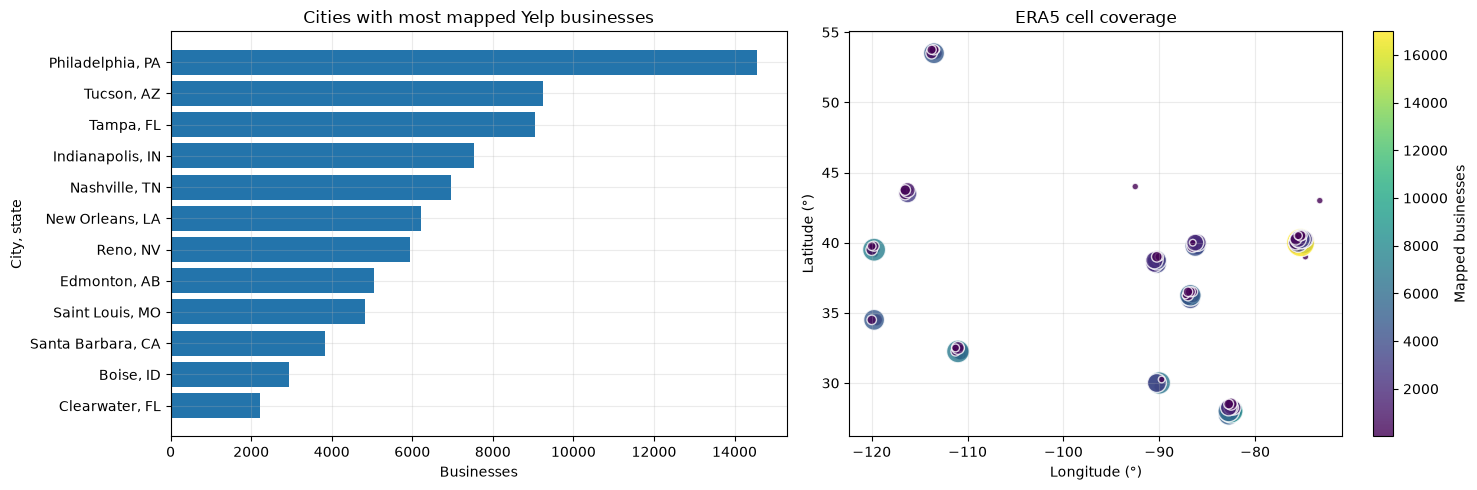

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
top_cities = city_coverage.head(12).iloc[::-1]
labels = top_cities.city.fillna("(missing)") + ", " + top_cities.state.fillna("(missing)")
axes[0].barh(labels, top_cities.businesses, color="#2374ab")
axes[0].set(
    title="Cities with most mapped Yelp businesses", xlabel="Businesses", ylabel="City, state"
)
points = axes[1].scatter(
    cells.longitude,
    cells.latitude,
    s=20 + np.sqrt(cells.business_count) * 3,
    c=cells.business_count,
    cmap="viridis",
    alpha=0.8,
    edgecolors="white",
)
axes[1].set(title="ERA5 cell coverage", xlabel="Longitude (°)", ylabel="Latitude (°)")
fig.colorbar(points, ax=axes[1], label="Mapped businesses")
plt.tight_layout()
plt.show()

## Results

### Complete UTC daily weather

Read every annual file in bounded chunks and verify its exact cell-hour sequence,
including chunk/year boundaries. Aggregate into small daily tables before combining;
the full hourly dataset is never loaded or expanded across businesses.

In [11]:
DAILY_KEYS = ["weather_cell_id", "date_utc"]
CORE_REDUCERS = {
    "sample_hours": "sum",
    "temperature_sum": "sum",
    "temperature_count": "sum",
    "temperature_min_c": "min",
    "temperature_max_c": "max",
    "humidity_sum": "sum",
    "humidity_count": "sum",
    "wind_sum": "sum",
    "wind_count": "sum",
    "wind_max_m_s": "max",
}
RAIN_REDUCERS = {
    "rain_sample_hours": "sum",
    "precipitation_observed_sum": "sum",
    "precipitation_count": "sum",
}


def daily_partials(chunk):
    """Return sufficient statistics for timestamp days and preceding-hour rain days."""
    core = chunk.assign(date_utc=chunk.timestamp_utc.dt.floor("D"))
    core = (
        core.groupby(DAILY_KEYS, observed=True)
        .agg(
            sample_hours=("timestamp_utc", "size"),
            temperature_sum=("temperature_2m", "sum"),
            temperature_count=("temperature_2m", "count"),
            temperature_min_c=("temperature_2m", "min"),
            temperature_max_c=("temperature_2m", "max"),
            humidity_sum=("relative_humidity_2m", "sum"),
            humidity_count=("relative_humidity_2m", "count"),
            wind_sum=("wind_speed_10m", "sum"),
            wind_count=("wind_speed_10m", "count"),
            wind_max_m_s=("wind_speed_10m", "max"),
        )
        .reset_index()
    )
    rain = chunk.assign(date_utc=(chunk.timestamp_utc - pd.Timedelta(hours=1)).dt.floor("D"))
    rain = (
        rain.groupby(DAILY_KEYS, observed=True)
        .agg(
            rain_sample_hours=("timestamp_utc", "size"),
            precipitation_observed_sum=("precipitation", "sum"),
            precipitation_count=("precipitation", "count"),
        )
        .reset_index()
    )
    rain.loc[rain.precipitation_count.eq(0), "precipitation_observed_sum"] = np.nan
    return core, rain

In [12]:
def combine_daily_partials(core_parts, rain_parts):
    core = (
        pd.concat(core_parts, ignore_index=True)
        .groupby(DAILY_KEYS, observed=True, as_index=False)
        .agg(CORE_REDUCERS)
    )
    rain = (
        pd.concat(rain_parts, ignore_index=True)
        .groupby(DAILY_KEYS, observed=True, as_index=False)
        .agg(RAIN_REDUCERS)
    )
    rain.loc[rain.precipitation_count.eq(0), "precipitation_observed_sum"] = np.nan
    daily = core.merge(rain, on=DAILY_KEYS, how="outer", validate="one_to_one")
    count_columns = [
        "sample_hours",
        "temperature_count",
        "humidity_count",
        "wind_count",
        "rain_sample_hours",
        "precipitation_count",
    ]
    daily[count_columns] = daily[count_columns].fillna(0).astype("int64")
    daily["temperature_mean_c"] = daily.temperature_sum / daily.temperature_count.replace(0, np.nan)
    daily["humidity_mean_percent"] = daily.humidity_sum / daily.humidity_count.replace(0, np.nan)
    daily["wind_mean_m_s"] = daily.wind_sum / daily.wind_count.replace(0, np.nan)
    daily["complete_core_day"] = (
        daily[["temperature_count", "humidity_count", "wind_count"]].eq(24).all(axis=1)
    )
    daily["complete_rain_day"] = daily.precipitation_count.eq(24)
    daily["complete_day"] = daily.complete_core_day & daily.complete_rain_day
    daily["precipitation_mm"] = daily.precipitation_observed_sum.where(daily.complete_rain_day)
    return daily.sort_values(DAILY_KEYS).reset_index(drop=True)

In [13]:
core_parts, rain_parts = [], []
hourly_rows = 0
previous_end = start_utc
for year in expected_years:
    declared = acquisition["partitions"][str(year)]
    filename = f"era5_{year}.csv.gz"
    assert declared["file"] == filename  # Use our basename, not an arbitrary manifest path.
    first_hour = max(start_utc, pd.Timestamp(f"{year}-01-01", tz="UTC"))
    after_last_hour = min(end_utc_exclusive, pd.Timestamp(f"{year + 1}-01-01", tz="UTC"))
    hours_per_cell = int((after_last_hour - first_hour) / pd.Timedelta(hours=1))
    assert first_hour == previous_end == pd.Timestamp(declared["first_timestamp_utc"])
    assert after_last_hour - pd.Timedelta(hours=1) == pd.Timestamp(declared["last_timestamp_utc"])
    assert hours_per_cell == declared["hours_per_cell"]
    assert declared["rows"] == hours_per_cell * len(cells)
    row_offset = 0
    reader = pd.read_csv(
        WEATHER_DIR / "hourly" / filename,
        usecols=HOURLY_COLUMNS,
        chunksize=CHUNK_ROWS,
        dtype={
            "weather_cell_id": "string",
            "timestamp_utc": "string",
            **{name: "float64" for name in VARIABLES},
        },
    )
    for chunk in reader:
        assert chunk.timestamp_utc.str.endswith("+00:00").all()
        chunk["timestamp_utc"] = pd.to_datetime(
            chunk.timestamp_utc, format="ISO8601", utc=True, errors="raise"
        )
        assert not np.isinf(chunk[VARIABLES].to_numpy()).any(), "Infinite weather value."
        positions = row_offset + np.arange(len(chunk), dtype=np.int64)
        assert np.all(positions < hours_per_cell * len(cells)), "Extra cell-hour rows."
        expected_cells = cell_order[positions // hours_per_cell]
        expected_ns = (
            first_hour.as_unit("ns").value + (positions % hours_per_cell) * 3_600_000_000_000
        )
        assert np.array_equal(chunk.weather_cell_id.to_numpy(), expected_cells), (
            "Wrong cell sequence."
        )
        assert np.array_equal(
            chunk.timestamp_utc.dt.as_unit("ns").astype("int64").to_numpy(), expected_ns
        ), "Duplicate/gapped UTC hours."
        row_offset += len(chunk)
        core_part, rain_part = daily_partials(chunk)
        core_parts.append(core_part)
        rain_parts.append(rain_part)
    assert row_offset == declared["rows"], f"Wrong row count in {filename}"
    hourly_rows += row_offset
    previous_end = after_last_hour
assert hourly_rows == expected_rows and previous_end == end_utc_exclusive
print(f"Read and checked {hourly_rows:,} rows across {len(expected_years)} annual files.")

Read and checked 11,737,584 rows across 14 annual files.


In [14]:
daily_all = combine_daily_partials(core_parts, rain_parts)
del core_parts, rain_parts
assert daily_all.sample_hours.sum() == daily_all.rain_sample_hours.sum() == hourly_rows
assert daily_all[["sample_hours", "rain_sample_hours"]].le(24).all().all()
daily_weather = daily_all[daily_all.complete_day].copy()
assert not daily_weather.duplicated(DAILY_KEYS).any()
assert len(daily_weather) == len(cells) * (expected_hours_per_cell // 24 - 1)
assert daily_weather.groupby("weather_cell_id").size().nunique() == 1
print(f"Complete daily rows: {len(daily_weather):,}")
print(
    f"Dates: {daily_weather.date_utc.min().date()} "
    f"through {daily_weather.date_utc.max().date()} UTC"
)
display(
    daily_weather[
        [
            "weather_cell_id",
            "date_utc",
            "temperature_mean_c",
            "temperature_min_c",
            "temperature_max_c",
            "humidity_mean_percent",
            "precipitation_mm",
            "wind_mean_m_s",
        ]
    ]
    .head()
    .round(
        {
            name: 3
            for name in [
                "temperature_mean_c",
                "temperature_min_c",
                "temperature_max_c",
                "humidity_mean_percent",
                "precipitation_mm",
                "wind_mean_m_s",
            ]
        }
    )
)

Complete daily rows: 488,955
Dates: 2009-12-29 through 2022-01-19 UTC


,weather_cell_id,date_utc,temperature_mean_c,temperature_min_c,temperature_max_c,humidity_mean_percent,precipitation_mm,wind_mean_m_s
1,era5_110_-330,2009-12-29 00:00:00+00:00,9.956,4.50,15.95,56.649,0.0,3.643
2,era5_110_-330,2009-12-30 00:00:00+00:00,12.181,5.95,21.85,68.857,0.0,2.740
3,era5_110_-330,2009-12-31 00:00:00+00:00,17.873,13.75,23.35,77.694,0.0,2.591
4,era5_110_-330,2010-01-01 00:00:00+00:00,17.919,12.05,20.30,89.828,8.5,3.715
5,era5_110_-330,2010-01-02 00:00:00+00:00,10.644,5.55,14.70,58.911,0.0,4.864


### Complete calendar months

Exclude partial December 2009 and January 2022. A cell-month must contain every calendar
day with 24 valid values per variable. Means combine hourly sums/counts; rain sums complete days.

In [15]:
daily_weather["year"] = daily_weather.date_utc.dt.year
daily_weather["month"] = daily_weather.date_utc.dt.month
monthly_candidates = (
    daily_weather.groupby(["weather_cell_id", "year", "month"], observed=True)
    .agg(
        complete_days=("date_utc", "size"),
        first_date_utc=("date_utc", "min"),
        last_date_utc=("date_utc", "max"),
        temperature_sum=("temperature_sum", "sum"),
        temperature_count=("temperature_count", "sum"),
        temperature_min_c=("temperature_min_c", "min"),
        temperature_max_c=("temperature_max_c", "max"),
        humidity_sum=("humidity_sum", "sum"),
        humidity_count=("humidity_count", "sum"),
        wind_sum=("wind_sum", "sum"),
        wind_count=("wind_count", "sum"),
        wind_max_m_s=("wind_max_m_s", "max"),
        precipitation_mm=("precipitation_mm", "sum"),
        precipitation_count=("precipitation_count", "sum"),
    )
    .reset_index()
)
monthly_candidates["expected_calendar_days"] = monthly_candidates.first_date_utc.dt.days_in_month
monthly_candidates["complete_month"] = monthly_candidates.complete_days.eq(
    monthly_candidates.expected_calendar_days
)
for count_column in ["temperature_count", "humidity_count", "wind_count", "precipitation_count"]:
    monthly_candidates["complete_month"] &= monthly_candidates[count_column].eq(
        monthly_candidates.expected_calendar_days * 24
    )
monthly_weather = monthly_candidates[monthly_candidates.complete_month].copy()
monthly_weather["temperature_mean_c"] = (
    monthly_weather.temperature_sum / monthly_weather.temperature_count
)
monthly_weather["humidity_mean_percent"] = (
    monthly_weather.humidity_sum / monthly_weather.humidity_count
)
monthly_weather["wind_mean_m_s"] = monthly_weather.wind_sum / monthly_weather.wind_count
assert not monthly_weather.duplicated(["weather_cell_id", "year", "month"]).any()
assert len(monthly_weather) == len(cells) * 12 * 12
assert monthly_weather.groupby(["weather_cell_id", "month"]).size().eq(12).all()
print(f"Complete monthly rows: {len(monthly_weather):,} (2010–2021)")
display(
    monthly_weather[
        [
            "weather_cell_id",
            "year",
            "month",
            "temperature_mean_c",
            "humidity_mean_percent",
            "precipitation_mm",
            "wind_mean_m_s",
        ]
    ]
    .head()
    .round(3)
)

Complete monthly rows: 15,984 (2010–2021)


,weather_cell_id,year,month,temperature_mean_c,humidity_mean_percent,precipitation_mm,wind_mean_m_s
1,era5_110_-330,2010,1,13.358,70.082,67.9,3.741
2,era5_110_-330,2010,2,13.244,69.570,78.5,3.838
3,era5_110_-330,2010,3,16.057,67.925,124.5,3.791
4,era5_110_-330,2010,4,22.093,67.577,59.5,3.361
5,era5_110_-330,2010,5,26.880,68.492,29.9,2.836


### Compare selected locations

For each exact city/state pair, choose its cell with the most mapped businesses.
The table shows its share of the city cohort. Seasonal curves average complete year-months
in 2010–2021 equally; they describe selected cells, not citywide 30-year climate normals.

In [16]:
city_cell_counts = (
    mapping.groupby(["city", "state", "weather_cell_id"], dropna=False)
    .size()
    .rename("city_businesses_in_cell")
    .reset_index()
)
selected_rows = []
for city, state in SELECTED_LOCATIONS:
    eligible = city_cell_counts[
        (city_cell_counts.city.eq(city) & city_cell_counts.state.eq(state)).fillna(False)
    ]
    if eligible.empty:
        raise ValueError(f"Location not found: {city}, {state}; choose from city_coverage.")
    chosen = (
        eligible.sort_values(
            ["city_businesses_in_cell", "weather_cell_id"], ascending=[False, True]
        )
        .iloc[0]
        .copy()
    )
    chosen["city_businesses_total"] = int(eligible.city_businesses_in_cell.sum())
    chosen["share_of_city_businesses"] = (
        chosen.city_businesses_in_cell / chosen.city_businesses_total
    )
    selected_rows.append(chosen)
selected_cells = pd.DataFrame(selected_rows).merge(
    cells[["weather_cell_id", "latitude", "longitude"]],
    on="weather_cell_id",
    validate="many_to_one",
)
selected_cells["label"] = selected_cells.city + ", " + selected_cells.state
seasonal_weather = (
    monthly_weather.groupby(["weather_cell_id", "month"], observed=True)
    .agg(
        temperature_mean_c=("temperature_mean_c", "mean"),
        precipitation_mean_monthly_mm=("precipitation_mm", "mean"),
    )
    .reset_index()
)
display(selected_cells.drop(columns="label").round(3))

,city,state,weather_cell_id,city_businesses_in_cell,city_businesses_total,share_of_city_businesses,latitude,longitude
0,Philadelphia,PA,era5_160_-301,12069,14567,0.829,40.0,-75.25
1,Edmonton,AB,era5_214_-454,4715,5054,0.933,53.5,-113.50
2,Tampa,FL,era5_112_-330,8048,9048,0.889,28.0,-82.50


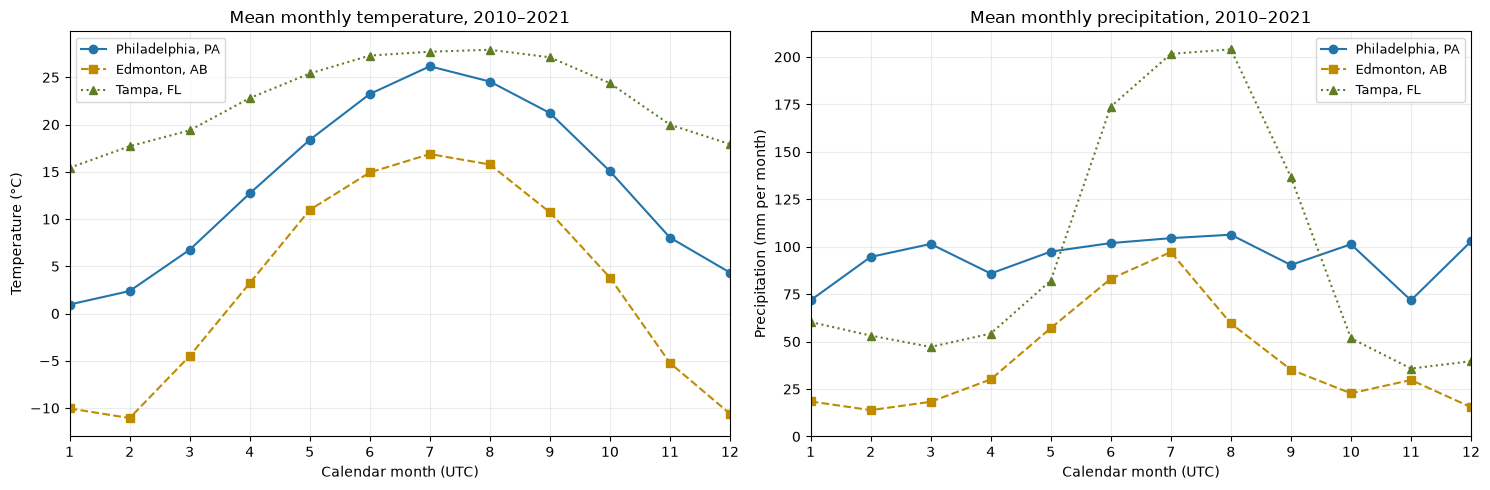

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
colors, line_styles, markers = ["#2374ab", "#bf8b00", "#617d24"], ["-", "--", ":"], ["o", "s", "^"]
for index, selected in selected_cells.iterrows():
    pattern = seasonal_weather[
        seasonal_weather.weather_cell_id.eq(selected.weather_cell_id)
    ].sort_values("month")
    style = {
        "marker": markers[index % 3],
        "linestyle": line_styles[index % 3],
        "color": colors[index % 3],
        "label": selected.label,
    }
    axes[0].plot(pattern.month, pattern.temperature_mean_c, **style)
    axes[1].plot(pattern.month, pattern.precipitation_mean_monthly_mm, **style)
axes[0].set(title="Mean monthly temperature, 2010–2021", ylabel="Temperature (°C)")
axes[1].set(
    title="Mean monthly precipitation, 2010–2021",
    ylabel="Precipitation (mm per month)",
    ylim=(0, None),
)
for axis in axes:
    axis.set(xlabel="Calendar month (UTC)", xticks=range(1, 13), xlim=(1, 12))
    axis.legend(fontsize=9)
plt.tight_layout()
plt.show()

### Export daily and monthly weather

Save only the two complete cell-level weather tables under `OUTPUT_DIR`.
The downloaded inputs remain untouched. Retain Open-Meteo/Copernicus attribution when sharing.

In [18]:
daily_export_columns = [
    "weather_cell_id",
    "date_utc",
    "temperature_mean_c",
    "temperature_min_c",
    "temperature_max_c",
    "humidity_mean_percent",
    "precipitation_mm",
    "wind_mean_m_s",
    "wind_max_m_s",
]
monthly_export_columns = [
    "weather_cell_id",
    "year",
    "month",
    "temperature_mean_c",
    "temperature_min_c",
    "temperature_max_c",
    "humidity_mean_percent",
    "precipitation_mm",
    "wind_mean_m_s",
    "wind_max_m_s",
]
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
daily_weather[daily_export_columns].to_csv(OUTPUT_DIR / "daily_weather_utc.csv.gz", index=False)
monthly_weather[monthly_export_columns].to_csv(
    OUTPUT_DIR / "monthly_weather_utc.csv.gz", index=False
)
print(f"Saved daily_weather_utc.csv.gz and monthly_weather_utc.csv.gz to {OUTPUT_DIR}")

Saved daily_weather_utc.csv.gz and monthly_weather_utc.csv.gz to /Users/hoadx/Workspace/mse/sitesense/data/processed/yelp_weather_exploration


## Takeaways

Weather stays once per cell, while the mapping retains every Yelp business. Use the
coverage table to choose a research cohort and the two exports to explore its weather.
Resolve Yelp timezone semantics before joining activity; historical patterns alone do not
establish weather effects or a location's commercial potential.